In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Import our geochemical analysis modules
try:
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
    from src import (
        GeochemicalSample,
        RegressionGroup, RegressionGroupCollection,
        clean_data, ci_norm_ree, convert_ppm2wtpc, add_geochemical_classifications, add_volcano_names,
        normalise_totals, molar_fraction, clr_transform, apply_compositional_transformation,
        regress_parallel, transpose_to_dict, filter_dictionary_by_independent_var,
        plot_regression_boxplots, plot_survival_function, plot_element_concentrations
    )
    print("✓ Modules imported successfully!")
    print(f"Working directory: {os.getcwd()}")
except ImportError as e:
    print(f"✗ Import error: {e}")
    print(f"Current working directory: {os.getcwd()}")
    print(f"Python path: {sys.path[:3]}")
    print("\nTroubleshooting:")
    print("1. Make sure you changed to the met4tech_BC directory before running the notebook")
    print("2. You can fix this by adding this as the first cell:")
    print("   %cd /Users/benclarke/Documents/LOCAL_NOTEBOOKS/met4tech_BC")
    raise

# Set up plotting
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10


/opt/anaconda3/envs/met4tech/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Modules imported successfully!
Working directory: /Users/benclarke/Documents/LOCAL_NOTEBOOKS/met4tech_BC/examples


# Geochemical Analysis Workflow

This notebook demonstrates the new modular approach to geochemical data analysis using the refactored Python modules. The workflow includes:

1. **Data Loading and Cleaning** - Load raw GEOROC data and apply cleaning functions
2. **Data Transformations** - Apply compositional transformations (normalization, CLR, etc.)
3. **Geochemical Classifications** - Add geochemical classification schemes
4. **Regression Analysis** - Perform statistical regression analyses
5. **Visualization** - Create plots and visualizations of results


## 1. Data Loading and Initial Setup

First, we'll load the raw GEOROC data and external reference datasets.


In [2]:
# Load the main dataset
df_raw = pd.read_csv('../DATA/R_arcs_edited.csv', low_memory=False)
print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)[:10]}...")  # Show first 10 columns

# Load external reference data
ci_data = pd.read_csv('../DATA/lambda_parameters.csv')
volcano_database = pd.read_csv('../DATA/GVP_HOLOCENE_VOLCS.csv')

print(f"\nCI data shape: {ci_data.shape}")
print(f"Volcano database shape: {volcano_database.shape}")


Raw dataset shape: (116569, 176)
Columns: ['Unnamed: 0', 'ID', 'GEOROC_ID', 'CITATIONS', 'TECTONIC SETTING', 'ARC_CODE', 'LOCATION', 'LOCATION COMMENT', 'LATITUDE MIN', 'LATITUDE MAX']...

CI data shape: (14, 3)
Volcano database shape: (1282, 14)


## 2. Data Cleaning

Apply comprehensive data cleaning using the modular functions.


In [3]:
# Define element lists (from GeochemicalSample class)
ELEMENTS = GeochemicalSample.ELEMENTS
PPM_ELEMENTS = GeochemicalSample.PPM_ELEMENTS
REE_ELEMENTS = GeochemicalSample.REE_ELEMENTS
ELEMENTS_MASS = GeochemicalSample.ELEMENTS_MASS

print(f"Total elements: {len(ELEMENTS)}")
print(f"PPM elements: {len(PPM_ELEMENTS)}")
print(f"REE elements: {len(REE_ELEMENTS)}")

# Step 1: Clean the raw data
print("\nStep 1: Cleaning raw data...")
df_clean = clean_data(df_raw, ELEMENTS, loi_threshold=3.5)
print(f"After cleaning: {df_clean.shape[0]} samples (removed {df_raw.shape[0] - df_clean.shape[0]} samples)")

# Step 2: Normalize REE elements to chondrite values
print("\nStep 2: Normalizing REE elements to chondrite values...")
df_clean = ci_norm_ree(df_clean, REE_ELEMENTS, ci_data)
print(f"Added {len(REE_ELEMENTS)} CI-normalized REE columns")

# Step 3: Convert ppm elements to weight percent
print("\nStep 3: Converting ppm elements to weight percent...")
df_clean = convert_ppm2wtpc(df_clean, PPM_ELEMENTS)
print(f"Converted {len(PPM_ELEMENTS)} elements from ppm to wt%")

print(f"\nFinal cleaned dataset shape: {df_clean.shape}")


Total elements: 98
PPM elements: 71
REE elements: 14

Step 1: Cleaning raw data...
After cleaning: 32151 samples (removed 84418 samples)

Step 2: Normalizing REE elements to chondrite values...
Added 14 CI-normalized REE columns

Step 3: Converting ppm elements to weight percent...
Converted 71 elements from ppm to wt%

Final cleaned dataset shape: (32151, 190)


## 3. Object-Oriented Approach: Using GeochemicalSample Class

Demonstrate the object-oriented approach using an individual sample.


In [9]:
# Create a sample from the first row of data
# sample_id will automatically be set to GEOROC_ID if it exists in the data
sample_data = df_raw.iloc[16]
sample = GeochemicalSample(sample_data)

print(f"Created sample: {sample}")
print(f"Sample ID: {sample.sample_id}")
print(f"Raw data available: {sample.raw_data is not None}")
print(f"Cleaned data available: {sample.cleaned_data is not None}")

# Apply transformations to the sample
try:
    sample.clean().convert_ppm_to_wt().normalize_totals().clr_transform()
    
    print("\nSample transformations completed successfully!")
    print(f"Cleaned data available: {sample.cleaned_data is not None}")
    
    # Get some element concentrations in different units
    sio2_wt = sample.get_element_concentration('SIO2', 'wt')
    sio2_norm = sample.get_element_concentration('SIO2', 'norm')
    sio2_clr = sample.get_element_concentration('SIO2', 'clr')
    
    print(f"\nSiO2 concentrations:")
    print(f"  Weight %: {sio2_wt:.2f}")
    print(f"  Normalized: {sio2_norm:.4f}")
    print(f"  CLR: {sio2_clr:.4f}")
    
    # Calculate geochemical indices
    mg_number = sample.calculate_mg_number()
    sio2_class = sample.classify_sio2()
    
    print(f"\nGeochemical indices:")
    print(f"  Mg number: {mg_number:.3f}")
    print(f"  SiO2 class: {sio2_class}")
    
except Exception as e:
    print(f"Error processing sample: {e}")


sample.cleaned_data


Created sample: GeochemicalSample(id=108507, cleaned=False)
Sample ID: 108507
Raw data available: True
Cleaned data available: False

Sample transformations completed successfully!
Cleaned data available: True

SiO2 concentrations:
  Weight %: 71.71
  Normalized: 0.7187
  CLR: 3.7845

Geochemical indices:
  Mg number: 0.161
  SiO2 class: acid


Unnamed: 0                         16
ID                                 17
GEOROC_ID                      108507
CITATIONS                      [4826]
TECTONIC SETTING    CONVERGENT MARGIN
                          ...        
MNO_clr                     -3.013815
K2O_clr                      0.603837
NA2O_clr                     1.059476
P2O5_clr                    -3.147346
geom_mean                    0.016328
Name: 16, Length: 198, dtype: object

## 4. Functional Approach: Direct DataFrame Transformations

Instead of using the object-oriented approach, you can apply transformations directly to DataFrames using functional programming. This is useful for batch processing of entire datasets.

In [10]:
# Step 1: Normalize totals to 100%
print("Step 1: Normalizing element totals...")
df_func = normalise_totals(df_clean, ELEMENTS)
print(f"Normalization complete. Example totals:")
print(df_func[['calc_TOTAL']].describe())

# Step 2: Calculate molar fractions
print("\nStep 2: Calculating molar fractions...")
df_func = molar_fraction(df_func, ELEMENTS, ELEMENTS_MASS)
print(f"Molar fraction columns added")

# Step 3: Apply CLR transformation
print("\nStep 3: Applying center log-ratio (CLR) transformation...")
df_func = clr_transform(df_func, ELEMENTS)
print(f"CLR transformation complete")

# Step 4: Add geochemical classifications
print("\nStep 4: Adding geochemical classifications...")
df_func = add_geochemical_classifications(df_func)
print(f"Classifications added: class_SIO2, class_alkalic, class_LeMaitre, etc.")

print(f"\nFinal transformed dataset shape: {df_func.shape}")
print(f"\nSample of transformed columns:")
print([col for col in df_func.columns if any(x in col for x in ['_norm', '_clr', '_molfrac', 'class_'])][:15])


Step 1: Normalizing element totals...
Normalization complete. Example totals:
         calc_TOTAL
count  32151.000000
mean      98.928066
std        2.863612
min       41.851346
25%       98.177170
50%       99.103120
75%       99.766228
max      122.169450

Step 2: Calculating molar fractions...
Molar fraction columns added

Step 3: Applying center log-ratio (CLR) transformation...
CLR transformation complete

Step 4: Adding geochemical classifications...
Classifications added: class_SIO2, class_alkalic, class_LeMaitre, etc.

Final transformed dataset shape: (32151, 493)

Sample of transformed columns:
['SIO2_norm', 'TIO2_norm', 'B2O3_norm', 'AL2O3_norm', 'CR2O3_norm', 'FE2O3_norm', 'FEO_norm', 'FEOT_norm', 'CAO_norm', 'MGO_norm', 'MNO_norm', 'NIO_norm', 'K2O_norm', 'NA2O_norm', 'P2O5_norm']


In [11]:
# Compare a few samples using functional approach
print("Comparing SiO2 values across transformations:\n")

sample_indices = [16, 100, 500]  # Compare a few samples
comparison_data = []

for idx in sample_indices:
    if idx < len(df_func):
        sample_id = df_func.iloc[idx]['GEOROC_ID'] if 'GEOROC_ID' in df_func.columns else idx
        sio2_wt = df_func.iloc[idx]['SIO2']
        sio2_norm = df_func.iloc[idx].get('SIO2_norm', np.nan)
        sio2_clr = df_func.iloc[idx].get('SIO2_clr', np.nan)
        sio2_class = df_func.iloc[idx].get('class_SIO2', np.nan)
        
        comparison_data.append({
            'Sample ID': sample_id,
            'SiO2 (wt%)': f"{sio2_wt:.2f}" if pd.notna(sio2_wt) else "N/A",
            'SiO2 (normalized)': f"{sio2_norm:.4f}" if pd.notna(sio2_norm) else "N/A",
            'SiO2 (CLR)': f"{sio2_clr:.4f}" if pd.notna(sio2_clr) else "N/A",
            'SiO2 Class': sio2_class if pd.notna(sio2_class) else "N/A"
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


Comparing SiO2 values across transformations:

Sample ID SiO2 (wt%) SiO2 (normalized) SiO2 (CLR)   SiO2 Class
  1125912      51.80            0.5401     8.7105 intermediate
   173284      51.14            0.5197     9.1511        basic
   399542      52.88            0.5285     6.6792 intermediate


## 5. Regression Analysis

Perform statistical regression analyses on the transformed data. This section demonstrates:
- **Object-Oriented Approach**: Using `RegressionGroup` and `RegressionGroupCollection` for easy inspection and analysis
- **Traditional Approach**: Using dictionary-based functions (still supported for backward compatibility)
- Run parallel regressions across different groups
- Extract and filter regression results
- Visualize regression results using boxplots and survival functions


In [12]:
# Prepare data for regression analysis
# We'll use CLR-transformed data for compositional regression
print("Preparing data for regression analysis...")

# Select a subset of major elements for regression (using CLR-transformed values)
major_elements_clr = ['SIO2_clr', 'TIO2_clr', 'AL2O3_clr', 'FEO_clr', 'MGO_clr', 'CAO_clr', 'NA2O_clr', 'K2O_clr']
independent_vars = ['SIO2_clr']  # Use SiO2 as independent variable
dependent_vars = [elem for elem in major_elements_clr if elem != 'SIO2_clr']  # All other elements as dependent

# Check data availability
print(f"\nIndependent variable: {independent_vars[0]}")
print(f"Dependent variables: {dependent_vars}")
print(f"\nChecking data completeness...")

# Filter to samples with required CLR data
required_cols = independent_vars + dependent_vars + ['ARC_CODE']  # Group by arc
df_reg = df_func.dropna(subset=required_cols)

print(f"Samples with complete CLR data: {len(df_reg)}")
print(f"Number of arcs: {df_reg['ARC_CODE'].nunique()}")
print(f"\nSample arc codes: {sorted(df_reg['ARC_CODE'].unique())[:10]}")


Preparing data for regression analysis...

Independent variable: SIO2_clr
Dependent variables: ['TIO2_clr', 'AL2O3_clr', 'FEO_clr', 'MGO_clr', 'CAO_clr', 'NA2O_clr', 'K2O_clr']

Checking data completeness...
Samples with complete CLR data: 8393
Number of arcs: 33

Sample arc codes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [ ]:
# Perform parallel regression analysis grouped by arc
print("Running parallel regression analysis...")
print("This may take a minute depending on the number of groups...\n")

# Option 1: Create RegressionGroupCollection directly (recommended)
print("Option 1: Creating RegressionGroupCollection directly...")
groups = regress_parallel(
    df_reg,
    group_column='ARC_CODE',
    independent_vars=independent_vars,
    dependent_vars=dependent_vars,
    n_jobs=-1,  # Use all available CPU cores
    return_groups=True  # Return RegressionGroupCollection instead of dict
)

print(f"\nRegression complete!")
print(f"Number of groups (arcs) analyzed: {len(groups)}")
print(f"Available groups: {groups.list_groups()[:10]}...")  # Show first 10

# Check how many regressions were successful
total_regressions = sum(len(group) for group in groups)
print(f"Total regression pairs computed: {total_regressions}")

# Option 2: Also get dictionary format (for backward compatibility)
print("\nOption 2: Converting to dictionary format (for backward compatibility)...")
regression_results = groups.to_dict()
print(f"Dictionary format also available with {len(regression_results)} groups")


Running parallel regression analysis...
This may take a minute depending on the number of groups...


Regression complete!
Number of groups (arcs) analyzed: 33
Sample groups: [1, 2, 3, 4, 5]
Total regression pairs computed: 231


In [ ]:
## 5a. Inspecting Regression Results

Demonstrate how to inspect regression results using the object-oriented RegressionGroupCollection approach.

### Inspecting Individual Groups and Regression Pairs


Example regression pair: SIO2_clr vs TIO2_clr

Arcs with data for this pair: 33

Statistics for SIO2_clr vs TIO2_clr:
  Mean R²: 0.8694
  Median R²: 0.8958
  Mean slope: 0.9436
  Significant relationships (p < 0.05): 32/33

Example results for first few arcs:
  1: R²=0.8309, p=0.0000, slope=1.0498
  2: R²=0.9162, p=0.0000, slope=0.9663
  3: R²=0.9619, p=0.0000, slope=0.9224
  4: R²=0.8377, p=0.0000, slope=0.9666
  5: R²=0.9180, p=0.0000, slope=1.0486


In [ ]:
# Examine regression results for a specific element pair
example_pair = (independent_vars[0], dependent_vars[0])  # e.g., (SIO2_clr, TIO2_clr)
print(f"Example regression pair: {example_pair[0]} vs {example_pair[1]}\n")

# Using RegressionGroupCollection (object-oriented approach)
print("Object-oriented access with RegressionGroupCollection:")
print("="*60)

# Collect statistics across all groups for this pair
r_squared_values = []
p_values = []
slopes = []
arcs_with_data = []

for group_id in groups.list_groups():
    group = groups.get_group(group_id)
    regression_result = group.get_regression(example_pair[0], example_pair[1])
    if regression_result:
        r_squared_values.append(regression_result['r_squared'])
        p_values.append(regression_result['p_value'])
        slopes.append(regression_result['coefficients'])
        arcs_with_data.append(group_id)

print(f"Arcs with data for this pair: {len(arcs_with_data)}")
if arcs_with_data:
    print(f"\nStatistics for {example_pair[0]} vs {example_pair[1]}:")
    print(f"  Mean R²: {np.mean(r_squared_values):.4f}")
    print(f"  Median R²: {np.median(r_squared_values):.4f}")
    print(f"  Mean slope: {np.mean(slopes):.4f}")
    print(f"  Significant relationships (p < 0.05): {sum(1 for p in p_values if p < 0.05)}/{len(p_values)}")
    print(f"\nExample results for first few arcs:")
    for i, arc in enumerate(arcs_with_data[:5]):
        group = groups.get_group(arc)
        result = group.get_regression(example_pair[0], example_pair[1])
        print(f"  {arc}: R²={result['r_squared']:.4f}, p={result['p_value']:.4f}, slope={result['coefficients']:.4f}")

# Inspect a specific group in detail
example_arc_id = arcs_with_data[0] if arcs_with_data else groups.list_groups()[0]
arc_group = groups.get_group(example_arc_id)
if arc_group:
    print(f"\n" + "="*60)
    print(f"Detailed inspection of group {example_arc_id}:")
    print("="*60)
    print(f"  Number of regressions: {len(arc_group)}")
    print(f"  Independent variables: {arc_group.list_independent_vars()}")
    print(f"  Dependent variables for {independent_vars[0]}: {arc_group.list_dependent_vars(independent_vars[0])}")
    
    # Get a specific regression
    regression_result = arc_group.get_regression(example_pair[0], example_pair[1])
    if regression_result:
        print(f"\n  Regression for {example_pair[0]} vs {example_pair[1]}:")
        print(f"    R²: {regression_result['r_squared']:.4f}")
        print(f"    P-value: {regression_result['p_value']:.4f}")
        print(f"    Slope: {regression_result['coefficients']:.4f}")
        print(f"    N observations: {regression_result['n_obs']}")
    
    # Get summary statistics for this group
    summary = arc_group.get_summary_stats()
    print(f"\n  Summary statistics for group {example_arc_id}:")
    print(f"    Total regressions: {summary['n_regressions']}")
    print(f"    Mean R²: {summary['mean_r2']:.4f}")
    print(f"    Significant regressions: {summary['significant_count']}/{summary['n_regressions']}")
    print(f"    Mean slope: {summary['mean_slope']:.4f}")


### Collection-Level Statistics and Operations


In [ ]:
# Demonstrate RegressionGroupCollection capabilities

# Option 1: Create from existing dictionary (as we did above)
print("Option 1: Create RegressionGroupCollection from dictionary")
print(f"Collection contains {len(groups)} groups\n")

# Option 2: Create directly from regress_parallel with return_groups=True
print("Option 2: Create directly from regress_parallel()")
groups_direct = regress_parallel(
    df_reg,
    group_column='ARC_CODE',
    independent_vars=independent_vars,
    dependent_vars=dependent_vars,
    n_jobs=-1,
    return_groups=True  # Return RegressionGroupCollection instead of dict
)
print(f"Directly created collection with {len(groups_direct)} groups\n")

# Collection-level statistics
print("Collection-wide statistics:")
collection_stats = groups.get_collection_stats()
for key, value in collection_stats.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# List available groups
print(f"\nAvailable groups: {groups.list_groups()[:10]}...")  # Show first 10


In [ ]:
# Filtering and extraction examples

# Filter groups to only include significant regressions
print("Filtering groups to significant regressions only (p < 0.05)...")
significant_groups = groups.filter_all_significant(p_threshold=0.05)
print(f"Original groups: {len(groups)}")
print(f"After filtering: {len(significant_groups)} groups with significant regressions\n")

# Extract data for boxplots (this is what plot_boxplots uses internally)
print("Extracting slopes for boxplot visualization...")
boxplot_data = groups.extract_for_boxplots(
    parameter='coefficients',  # Extract slopes
    p_threshold=0.05,  # Only significant relationships
    min_samples=5  # At least 5 observations
)

print(f"Extracted data for {len(boxplot_data)} regression pairs")
print("\nExample: Distribution of slopes across arcs for SIO2_clr vs TIO2_clr")
example_pair = (independent_vars[0], dependent_vars[0])
if example_pair in boxplot_data:
    slopes = boxplot_data[example_pair]
    print(f"  Number of arcs: {len(slopes)}")
    print(f"  Mean slope: {np.mean(slopes):.4f}")
    print(f"  Median slope: {np.median(slopes):.4f}")
    print(f"  Range: [{np.min(slopes):.4f}, {np.max(slopes):.4f}]")

# Compare two specific groups
if len(groups.list_groups()) >= 2:
    group_ids = groups.list_groups()[:2]
    print(f"\nComparing groups {group_ids[0]} and {group_ids[1]}:")
    comparison = groups.compare_groups(
        group_ids[0], group_ids[1],
        independent_vars[0], dependent_vars[0]
    )
    if comparison:
        print(f"  Slope difference: {comparison['slope_diff']:.4f}")
        print(f"  R² difference: {comparison['r2_diff']:.4f}")
        print(f"  P-value (group {group_ids[0]}): {comparison['p_value_group1']:.4f}")
        print(f"  P-value (group {group_ids[1]}): {comparison['p_value_group2']:.4f}")


In [ ]:
# Create boxplots using the object-oriented approach
print("Creating boxplots using RegressionGroupCollection...\n")

# Method 1: Extract data and use existing plotting function
boxplot_data = groups.extract_for_boxplots(
    parameter='coefficients',
    p_threshold=0.05,
    min_samples=5
)

# Filter to pairs with sufficient groups for meaningful boxplots
min_groups = 5
filtered_boxplot_data = {
    k: v for k, v in boxplot_data.items() 
    if len([x for x in v if not np.isnan(x)]) >= min_groups
}

if len(filtered_boxplot_data) > 0:
    print(f"Creating boxplots for {len(filtered_boxplot_data)} element pairs...")
    plot_regression_boxplots(
        filtered_boxplot_data,
        independent_vars=independent_vars,
        group_feature='ARC_CODE',
        p_value_threshold=0.05,
        n_samples_threshold=5,
        min_length=min_groups,
        figsize=(14, 10)
    )
else:
    print("Note: Not enough data for boxplots with current filters.")
    print("Using less strict filters for demonstration...\n")
    
    # Try with relaxed filters
    relaxed_data = groups.extract_for_boxplots(
        parameter='coefficients',
        p_threshold=None,  # No p-value filter
        min_samples=None   # No sample size filter
    )
    
    filtered_relaxed = {
        k: v for k, v in relaxed_data.items() 
        if len([x for x in v if not np.isnan(x)]) >= 3  # Lower threshold
    }
    
    if len(filtered_relaxed) > 0:
        print(f"Creating boxplots with relaxed filters ({len(filtered_relaxed)} pairs)...")
        plot_regression_boxplots(
            filtered_relaxed,
            independent_vars=independent_vars,
            group_feature='ARC_CODE',
            p_value_threshold=0.95,  # Higher threshold = less restrictive
            n_samples_threshold=1,   # Lower threshold
            min_length=3,
            figsize=(14, 10)
        )
    else:
        print("Still insufficient data. Showing alternative visualization...")
        # Show scatter plots instead
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()
        
        for idx, dep_var in enumerate(dependent_vars[:4]):
            ax = axes[idx]
            ax.scatter(df_reg[independent_vars[0]], df_reg[dep_var], alpha=0.3, s=10)
            ax.set_xlabel(independent_vars[0])
            ax.set_ylabel(dep_var)
            ax.set_title(f'{independent_vars[0]} vs {dep_var}')
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()


In [ ]:
# Method 2: Use the convenience plot_boxplots() method directly on the collection
print("\nAlternative: Using convenience method plot_boxplots() directly...\n")

# This method handles extraction and plotting in one step
try:
    groups.plot_boxplots(
        independent_vars=independent_vars,
        group_feature='ARC_CODE',
        parameter='coefficients',
        p_value_threshold=0.05,
        n_samples_threshold=5,
        min_length=3,  # Lower threshold for demonstration
        figsize=(14, 10)
    )
except Exception as e:
    print(f"Note: {e}")
    print("This is expected if there aren't enough groups meeting the criteria.")
    print("You can lower the thresholds or check your data.")


In [ ]:
# Export and data access examples

# Convert to DataFrame for easy analysis
print("Converting regression results to DataFrame...")
df_results = groups.to_dataframe()
print(f"DataFrame shape: {df_results.shape}")
print("\nFirst few rows:")
print(df_results[['group_id', 'independent_var', 'dependent_var', 'coefficients', 'r_squared', 'p_value']].head(10))

# Export to CSV
# Uncomment to export:
# groups.export_to_csv('../results/regression_results.csv')

# Access individual group statistics
print("\n" + "="*60)
print("Group-level statistics examples:")
print("="*60)
for group_id in groups.list_groups()[:3]:  # Show first 3 groups
    group = groups.get_group(group_id)
    stats = group.get_summary_stats()
    print(f"\nGroup {group_id}:")
    print(f"  Regressions: {stats['n_regressions']}")
    print(f"  Mean R²: {stats['mean_r2']:.4f}")
    print(f"  Significant: {stats['significant_count']}/{stats['n_regressions']}")
    print(f"  Mean slope: {stats['mean_slope']:.4f}")


In [24]:
# Extract and organize regression slopes for visualization
print("Extracting regression slopes for visualization...\n")

# Create regression pairs list
regression_pairs = [(indep, dep) for indep in independent_vars for dep in dependent_vars]

# Extract slopes with filtering (only significant relationships with sufficient samples)
results_dict = transpose_to_dict(
    regression_results,
    regression_pairs,
    parameter='coefficients',  # Extract slopes
    threshold_parameter='p_value',
    threshold=0.2  # Only include significant relationships
)

print(f"Regression pairs analyzed: {len(results_dict)}")
print(f"Filtered to significant relationships only (p < threshold)\n")

# Show summary for each dependent variable
for pair, values in list(results_dict.items())[:5]:
    if len(values) > 0:
        clean_values = [v for v in values if not np.isnan(v)]
        if len(clean_values) > 0:
            print(f"{pair[0]} vs {pair[1]}: {len(clean_values)} groups, "
                  f"mean slope={np.mean(clean_values):.4f}, "
                  f"median slope={np.median(clean_values):.4f}")


Extracting regression slopes for visualization...

Regression pairs analyzed: 7
Filtered to significant relationships only (p < threshold)

SIO2_clr vs FEO_clr: 1 groups, mean slope=-0.3124, median slope=-0.3124
SIO2_clr vs MGO_clr: 1 groups, mean slope=-1.6629, median slope=-1.6629
SIO2_clr vs CAO_clr: 1 groups, mean slope=-0.5995, median slope=-0.5995


In [27]:
# Filter results by independent variable for plotting
# This focuses on SiO2 as the independent variable
filtered_results = filter_dictionary_by_independent_var(results_dict, independent_vars[0])

print(f"Filtered results for {independent_vars[0]} as independent variable:")
print(f"Number of element pairs: {len(filtered_results)}\n")

# Filter to only include pairs with sufficient groups for meaningful boxplots
min_groups = 5
filtered_results = {k: v for k, v in filtered_results.items() if len([x for x in v if not np.isnan(x)]) >= min_groups}

print(f"After filtering to {min_groups}+ groups: {len(filtered_results)} pairs remain")

if len(filtered_results) > 0:
    print("\nPairs ready for visualization:")
    for pair, values in list(filtered_results.items()):
        clean_values = [v for v in values if not np.isnan(v)]
        print(f"  {pair[1]}: {len(clean_values)} groups")
else:
    print("\nNote: Not enough data for boxplots with current filters.")
    print("You may want to relax the p-value threshold or check data availability.")


Filtered results for SIO2_clr as independent variable:
Number of element pairs: 7

After filtering to 5+ groups: 0 pairs remain

Note: Not enough data for boxplots with current filters.
You may want to relax the p-value threshold or check data availability.


Insufficient data for boxplots. Creating scatter plot instead...



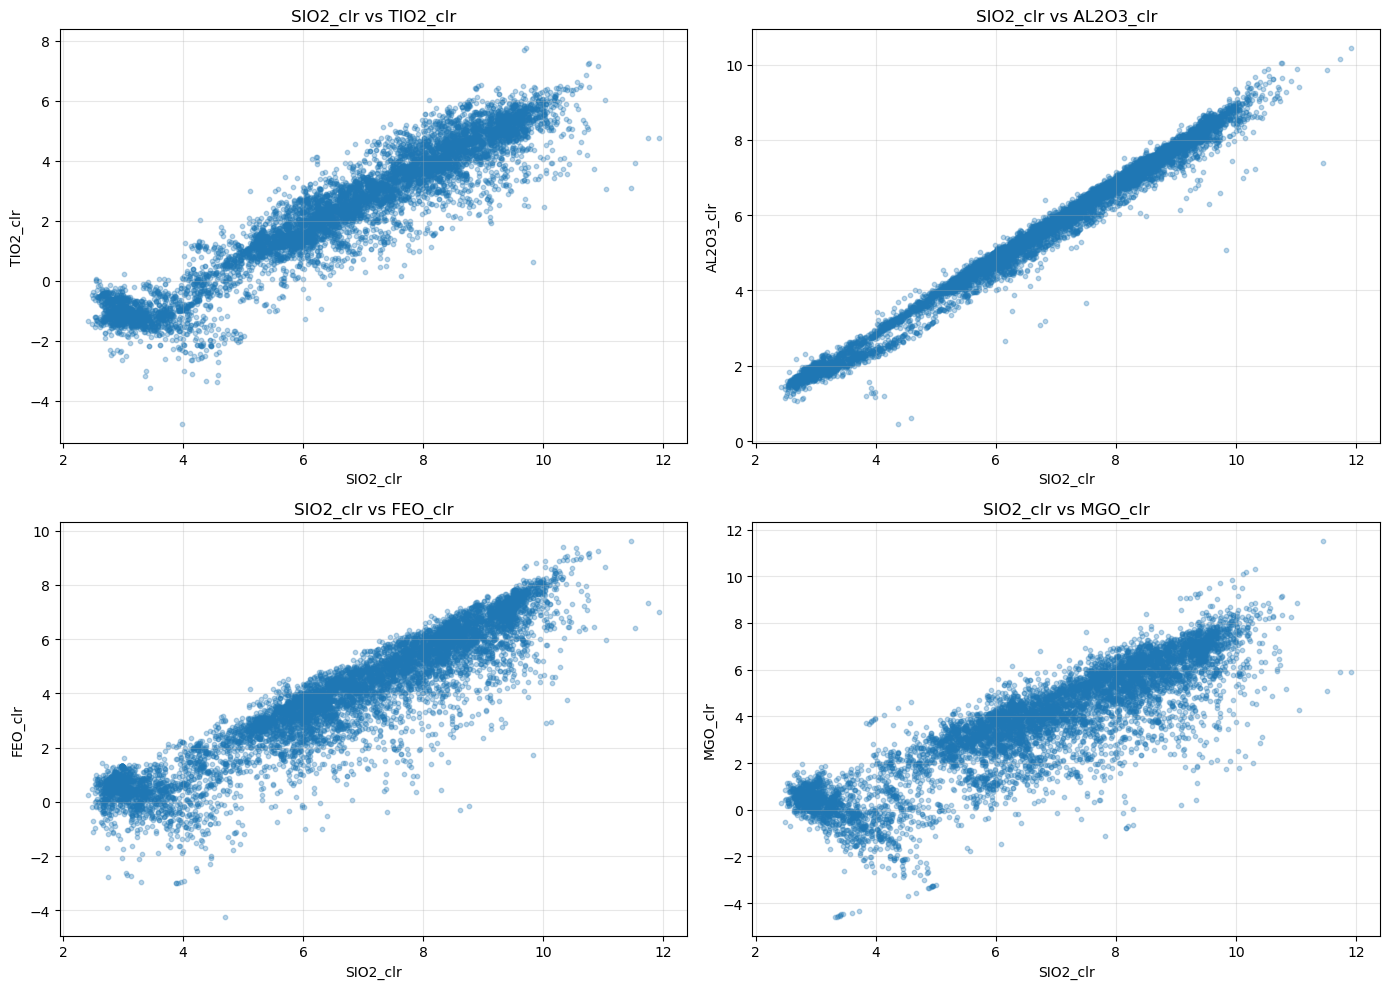

In [ ]:
# Method 1: Using RegressionGroupCollection (Recommended)
print("Method 1: Using RegressionGroupCollection directly...")
print("This is the recommended approach - simpler and more intuitive.\n")

# The plot_regression_boxplots function can accept RegressionGroupCollection directly
boxplot_data = groups.extract_for_boxplots(
    parameter='coefficients',
    p_threshold=0.05,
    min_samples=5
)

# Filter to pairs with sufficient groups
min_groups = 5
filtered_boxplot_data = {
    k: v for k, v in boxplot_data.items() 
    if len([x for x in v if not np.isnan(x)]) >= min_groups
}

if len(filtered_boxplot_data) > 0:
    print(f"Creating boxplots for {len(filtered_boxplot_data)} element pairs...")
    plot_regression_boxplots(
        filtered_boxplot_data,
        independent_vars=independent_vars,
        group_feature='ARC_CODE',
        p_value_threshold=0.05,
        n_samples_threshold=5,
        min_length=min_groups,
        figsize=(14, 10)
    )
else:
    print("Insufficient data for boxplots with strict filters.")
    print("The convenience method plot_boxplots() with relaxed filters is shown in earlier cells.")
    print("\nAlternative visualization: Scatter plots...\n")
    
    # Show scatter plots instead
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, dep_var in enumerate(dependent_vars[:4]):
        ax = axes[idx]
        ax.scatter(df_reg[independent_vars[0]], df_reg[dep_var], alpha=0.3, s=10)
        ax.set_xlabel(independent_vars[0])
        ax.set_ylabel(dep_var)
        ax.set_title(f'{independent_vars[0]} vs {dep_var}')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Method 2: Using dictionary format (also works - backward compatible)
print("\n" + "="*60)
print("Method 2: Using dictionary format (backward compatible)")
print("="*60)
print("plot_regression_boxplots() also accepts dictionary format from transpose_to_dict()")
print("Both methods produce identical results!")


Creating survival function plot for p-values...



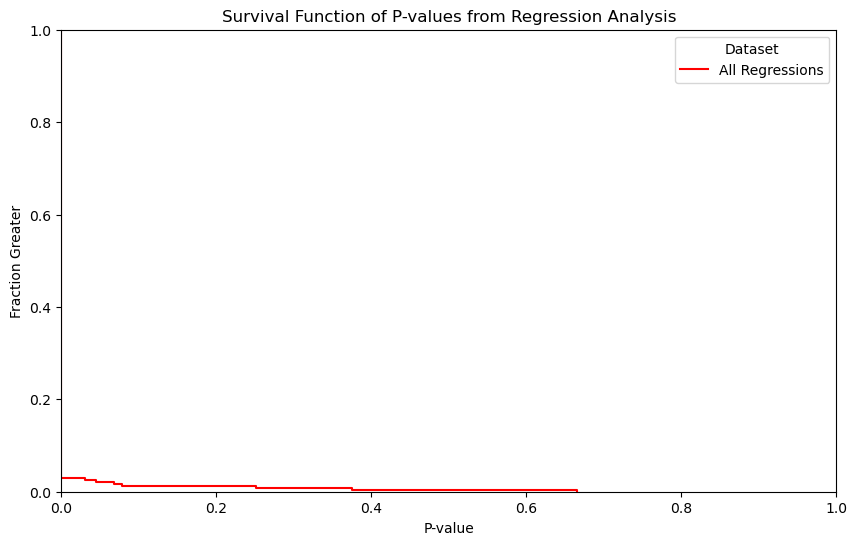

Total regressions: 231
Significant (p < 0.05): 226 (97.8%)
Highly significant (p < 0.01): 224
Mean p-value: 0.0066
Median p-value: 0.0000


In [ ]:
# Create survival function plot for p-values
# This shows the distribution of p-values across all regressions

print("Creating survival function plot for p-values...\n")

# Extract all p-values from regression results using object-oriented approach
all_p_values = []
for group in groups:
    for pair, result in group.regressions.items():
        all_p_values.append(result['p_value'])

# Alternative: Extract p-values using extract_for_boxplots method
# p_value_dict = groups.extract_for_boxplots(parameter='p_value')
# all_p_values = [val for sublist in p_value_dict.values() for val in sublist]

if all_p_values:
    # Plot survival function (requires a dictionary mapping dataset names to value lists)
    plot_survival_function(
        {'All Regressions': all_p_values},
        xlabel='P-value',
        ylabel='Fraction Greater',
        title='Survival Function of P-values from Regression Analysis',
        figsize=(10, 6)
    )
    
    # Print some statistics
    significant = sum(1 for p in all_p_values if p < 0.05)
    print(f"Total regressions: {len(all_p_values)}")
    print(f"Significant (p < 0.05): {significant} ({100*significant/len(all_p_values):.1f}%)")
    print(f"Highly significant (p < 0.01): {sum(1 for p in all_p_values if p < 0.01)}")
    print(f"Mean p-value: {np.mean(all_p_values):.4f}")
    print(f"Median p-value: {np.median(all_p_values):.4f}")
    
    # Collection-level statistics
    print(f"\nCollection-level statistics:")
    coll_stats = groups.get_collection_stats()
    print(f"  Number of groups: {coll_stats['n_groups']}")
    print(f"  Mean R² across all regressions: {coll_stats['mean_r2']:.4f}")
    print(f"  Mean slope across all regressions: {coll_stats['mean_slope']:.4f}")


## Summary

This notebook demonstrated both approaches to geochemical data analysis:

### Object-Oriented Approach
- **GeochemicalSample**: Individual sample handling with method chaining
  - `sample.clean().convert_ppm_to_wt().normalize_totals().clr_transform()`
  - Access transformed values via methods like `get_element_concentration()`
  
- **RegressionGroup & RegressionGroupCollection**: Regression result management
  - `RegressionGroup`: Inspect and filter regressions for a single group
  - `RegressionGroupCollection`: Manage multiple groups, extract for visualization
  - Methods: `get_group()`, `extract_for_boxplots()`, `filter_all_significant()`, `plot_boxplots()`
  - Create directly: `regress_parallel(..., return_groups=True)`

### Functional Approach  
- Apply transformations directly to DataFrames
- Functions like `normalise_totals()`, `molar_fraction()`, `clr_transform()`
- Better suited for batch processing entire datasets
- Traditional dictionary-based regression result access (still supported)

### Regression Analysis
- **Recommended**: Use `RegressionGroupCollection` for object-oriented access
  - Easy inspection: `groups.get_group(id).get_regression(ind, dep)`
  - Automatic filtering: `groups.filter_all_significant(p_threshold=0.05)`
  - Boxplot support: `groups.extract_for_boxplots()` or `groups.plot_boxplots()`
  - Statistics: `groups.get_collection_stats()`, `group.get_summary_stats()`
  - Comparison: `groups.compare_groups(id1, id2, ind, dep)`
- **Alternative**: Dictionary format with `transpose_to_dict()` and filtering functions
- Visualization: `plot_regression_boxplots()` accepts both dict and `RegressionGroupCollection`
- All approaches produce equivalent results - choose based on your workflow preferences!
